## Clustering

# ML - Aprendizaje No Supervisado

En la mayoría de los casos, nuestros datos no vienen con etiquetas. Etiquetarlos manualmente puede ser costoso y llevar mucho tiempo. Por eso existen técnicas de aprendizaje no supervisado (*Unsupervised Learning*), que nos permiten analizar y descubrir patrones en los datos sin necesidad de etiquetas previas.

El *Clustering* es una técnica popular de aprendizaje no supervisado que agrupa datos similares en conjuntos llamados *clusters*. Esto ayuda a descubrir patrones y segmentar información, siendo útil en áreas como la segmentación de clientes, análisis de datos, reducción de dimensiones, detección de anomalías y motores de búsqueda.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import random

In [5]:
n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-50, 50, size=2)
    if all(np.linalg.norm(candidate - center) > 15 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

X, y = make_blobs(n_samples=5000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers} centroides")
print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 17 centroides
Coordenadas de los centroides:
[[ 40.28876282   3.8936452 ]
 [-35.60400276  -3.88685253]
 [ 14.62461278  21.32608041]
 [ -2.49630869  28.14772209]
 [-21.91088317  24.12133476]
 [ 30.92299457  49.51829106]
 [ 44.59340323  42.96127163]
 [ 45.7196255  -27.61847334]
 [-23.27957974 -13.51201431]
 [  8.01399754  48.87648562]
 [ 40.22455081  22.22754069]
 [ 16.20783999 -20.00017694]
 [-18.78672487 -28.70389242]
 [-43.12791714 -39.29411811]
 [-18.99918494  40.23784403]
 [  3.16487732   2.74112317]
 [-47.84956151  48.7798646 ]]


In [6]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)


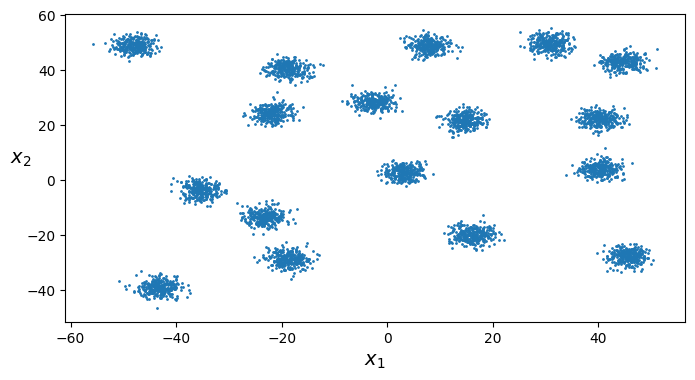

In [7]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()


En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.

In [8]:

k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred


array([12, 11,  5, ...,  5, 14,  9], shape=(5000,), dtype=int32)

In [9]:
kmeans.cluster_centers_

array([[  3.15686806,   2.69732607],
       [ 40.27571994,  22.11961902],
       [-18.85802401,  40.36488482],
       [-18.79148597, -28.80301418],
       [ 45.57983833, -27.72791797],
       [  7.80339863,  48.68286776],
       [-23.26349666, -13.47819552],
       [-47.93307905,  48.7920793 ],
       [ 16.19284676, -20.07003916],
       [ 44.62659583,  42.80657768],
       [ -2.62904676,  28.26114407],
       [-43.17826861, -39.14126511],
       [-21.87908081,  24.1393445 ],
       [ 14.70299037,  21.55879331],
       [ 30.84085081,  49.5143449 ],
       [-35.36450458,  -3.7528926 ],
       [ 40.26090377,   3.86909744]])

In [10]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)


array([0, 0, 0, 0], dtype=int32)

In [11]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z,  extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)


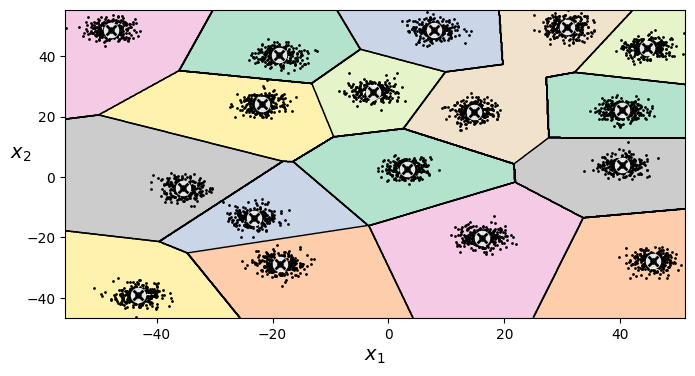

In [12]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()



En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [13]:
kmeans.transform(X_new)

array([[ 3.23296761, 45.02146917, 42.74914568, 36.08248367, 54.41755938,
        47.33057334, 27.94216909, 66.9856608 , 27.37325181, 60.47073538,
        26.3924151 , 59.64030998, 31.12627109, 24.46884389, 56.6460153 ,
        35.82937283, 40.30426649],
       [ 0.71475257, 42.35892311, 44.15470078, 37.73187702, 51.93064354,
        46.92933817, 30.48517334, 69.16413252, 25.71260069, 58.29193994,
        26.85765916, 61.84687694, 33.30344181, 22.79268258, 55.07019107,
        38.79343997, 37.30775355],
       [ 6.16430335, 47.31118016, 40.5907815 , 35.50778422, 57.48222016,
        46.94292097, 26.11781431, 64.15525014, 30.00986627, 62.07138033,
        25.2638676 , 58.2252479 , 28.34239894, 25.64809304, 57.52206068,
        33.06149899, 43.26963283],
       [ 6.16002937, 47.51544367, 41.05150945, 35.06065781, 57.21649864,
        47.42963943, 25.80527134, 64.51308549, 29.6272178 , 62.39321144,
        25.76381474, 57.86439517, 28.71725827, 26.01217927, 57.92712499,
        32.96300688

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de sus muestras asignadas.

In [14]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X); print(kmeans_iter1)
kmeans_iter2.fit(X); print(kmeans_iter2)
kmeans_iter3.fit(X); print(kmeans_iter3)


KMeans(algorithm='elkan', max_iter=3, n_clusters=17, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=17, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=17, n_init=1, random_state=5)


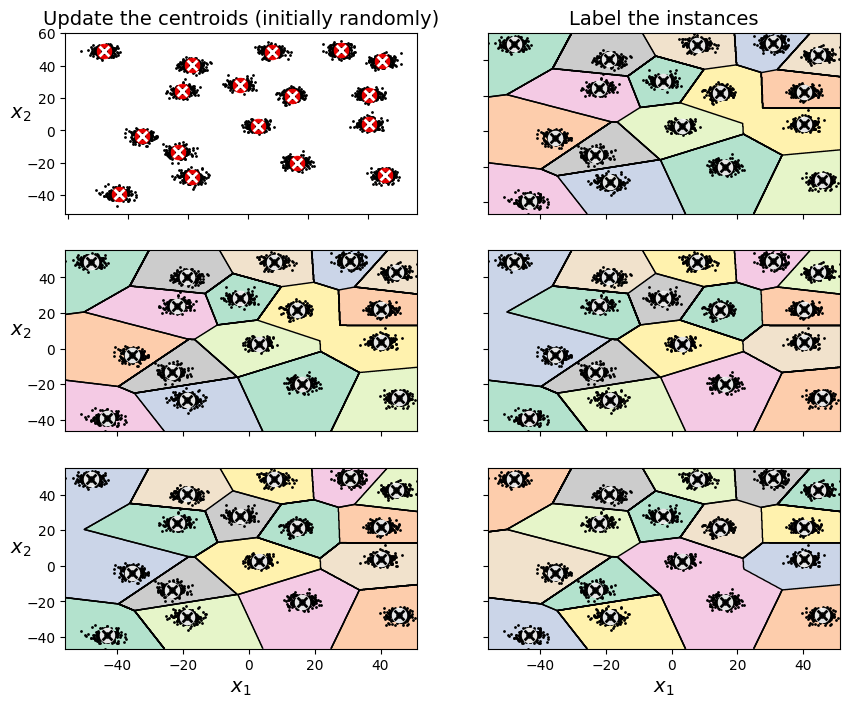

In [15]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()


Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [16]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)
    plt.figure(figsize=(10, 3.2))
    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)
    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)


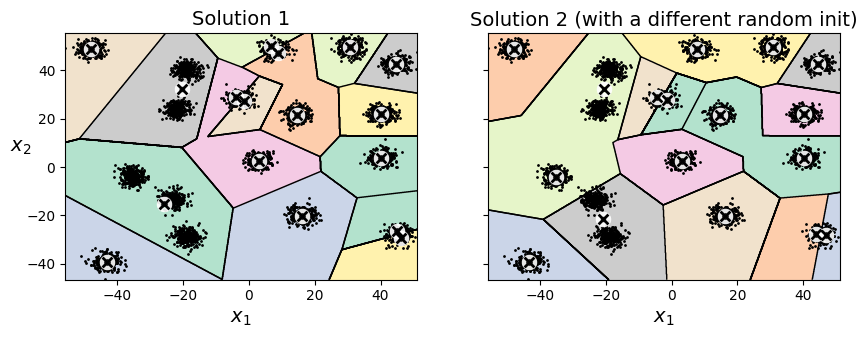

In [17]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                          algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                          algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1", "Solution 2 (with a different random init)")
plt.show()


Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente `k-means++`.

In [18]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)


KMeans(algorithm='elkan', init='random', n_clusters=17, n_init=10,
       random_state=11)


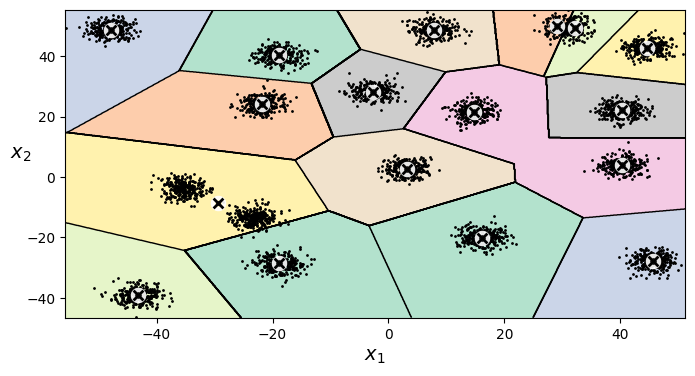

In [19]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()


Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas y también está el *mini-batch K-Means*, que trabaja con subconjuntos de datos en cada iteración.

In [20]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]


In [21]:
from sklearn.cluster import MiniBatchKMeans

k_mb = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k_mb, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)
    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_
    if (best_kmeans is None or
            minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans


In [22]:
best_kmeans.score(X)

-1431809.9180517136

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.



### Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el silhouette score, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.



In [23]:
from sklearn.metrics import silhouette_score
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
silhouette_score(X, kmeans.labels_)


0.809355048058266

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

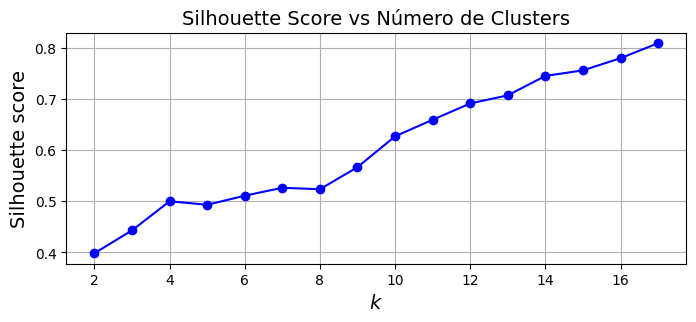

In [24]:
max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()


### ELBOW METHOD

Calcula la inercia para distintos valores de k

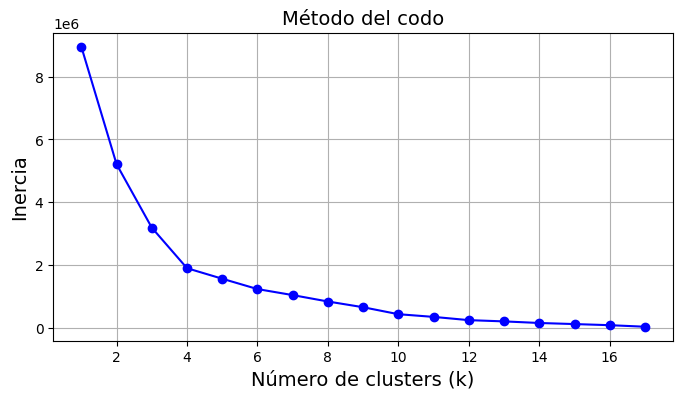

In [25]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()




También es muy útil visualizar los diagramas de silueta, en el que

*   Elemento de la lista
*   Elemento de la lista

visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

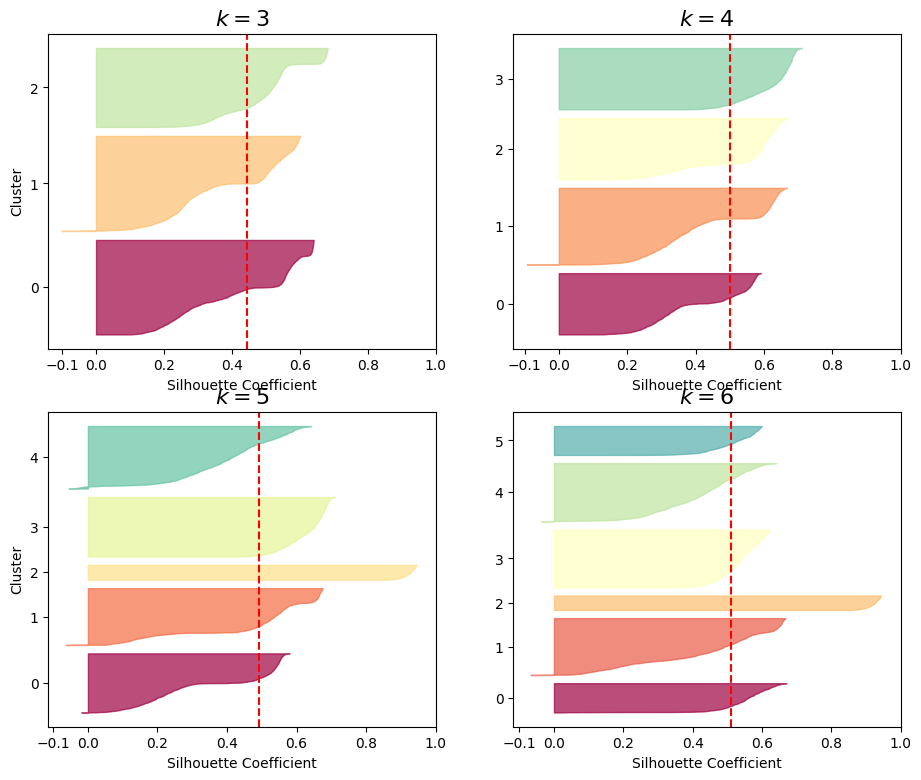

In [26]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()


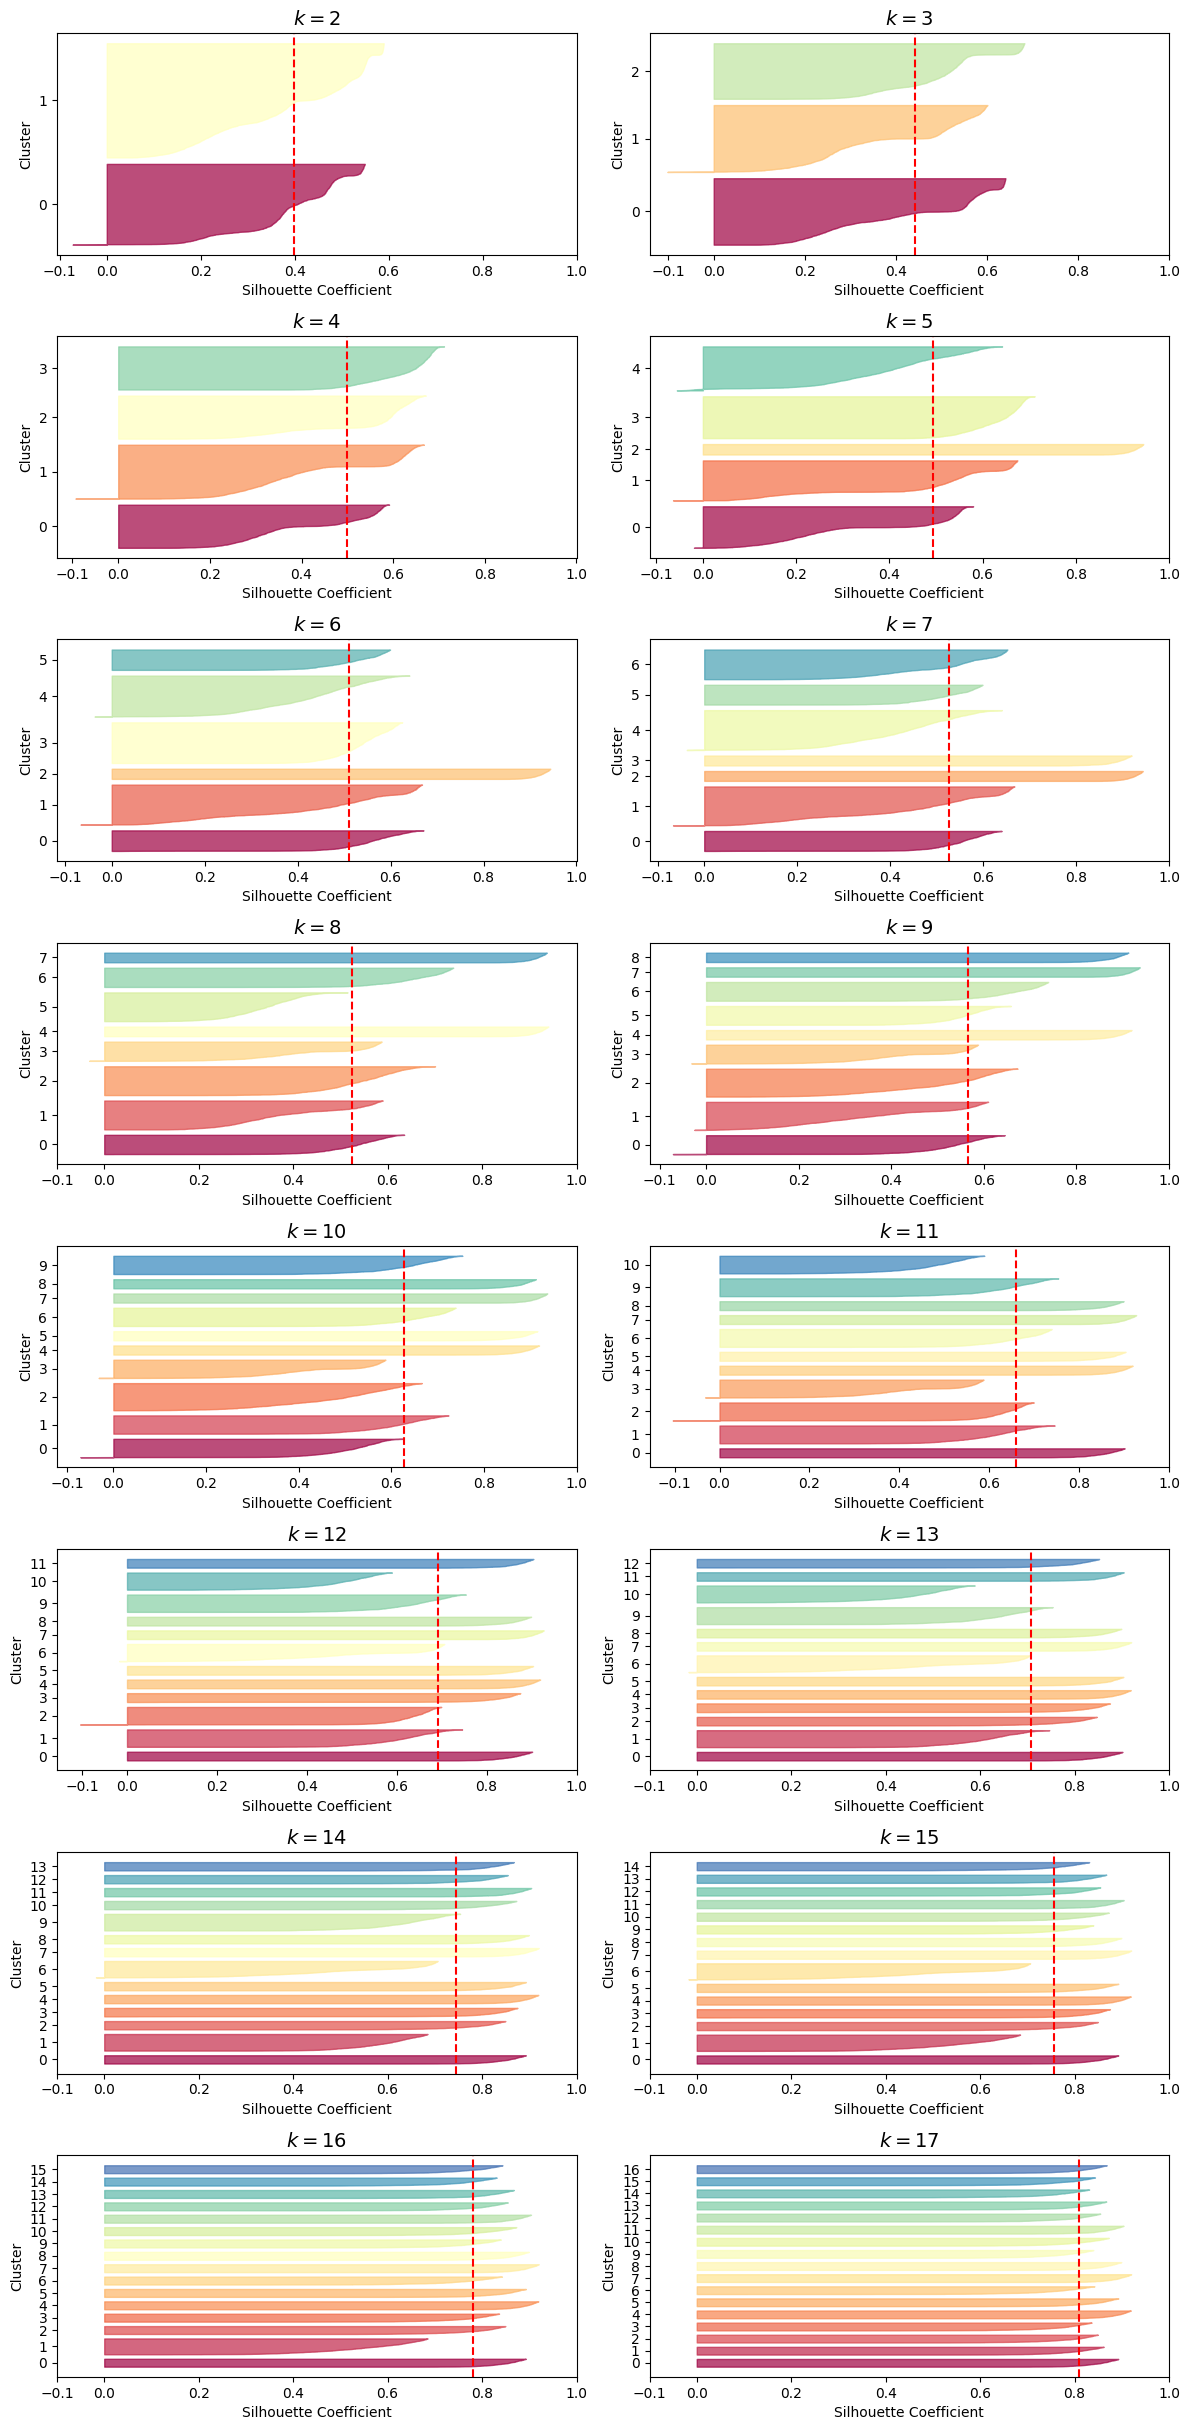

In [27]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))

for plot_idx, k in enumerate(range(2, n_ks + 1)):
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()
